# Forth practical work in Deep Learning course 
**Name:** Maha Kahla 


**Purpose of the laboratory work:** to study the principles of generative adversarial networks (GAN) on the example of the task of image generation from CIFAR-10 dataset. To compare the performance of two architectures: ordinary GAN and DCGAN (Deep Convolutional GAN).

The first thing we have to do is importing the necessary libraries that include the tools we need to implement the tasks

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

The following code is for loading and preprocessing the CIFAR-10 dataset, which consists of 60,000 32x32 color images containing one of 10 object classes, with 6000 images per class. The dataset images are first converted to PyTorch tensors, then, they are normalized. This improves convergence during training. additionally, we create the dataloaders which help in efficiently loading batches of data for training.
we load the dataset using torchvision, and it's already splitted into training and testing datasets.

In [2]:
# Load CIFAR-10 dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Scale images to range [-1, 1]
])

train_dataset = datasets.CIFAR10(root="./data", train=True, transform=transform, download=True)
test_dataset = datasets.CIFAR10(root="./data", train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

100%|██████████| 170M/170M [00:06<00:00, 26.9MB/s]


In [3]:
train_dataset

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )

In [4]:
test_dataset

Dataset CIFAR10
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )

Then we create the Generator and Discriminator networks for Generative Adversarial Network (GAN) model. In this case, the network is multi-layer perceptron (MLP). The Generator takes a random input (latent vector) and produces an image of size (3, 32, 32) (which matches CIFAR-10 images). The Discriminator takes an image (real or fake) and predicts whether it's real (1) or fake (0). The genearator consists of series of fully connected layers progressively increasing the number of neurons. the used activation function is ReLU, also Tanh is used to output pixel values in the range [-1, 1] (which matches the dataset normalization). The discriminator also consists of series of fully connected layers reducing the feature size. LeakyReLU is used to allow small negative values (helps prevent dying neurons). and finally sigmoid is used to output a probability score between 0 and 1.

In [5]:
# Generator model (MLP)
class Generator(nn.Module):
    def __init__(self, input_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 3*32*32),
            nn.Tanh()
        )
    def forward(self, x):
        return self.model(x).view(-1, 3, 32, 32)

# Discriminator model (MLP)
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(3 * 32 * 32, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.model(x)

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

We then initialize the Generator and Discriminator models for training a GAN and sets up the loss function and optimizers. The generator takes a 100-dimensional random vector as input as it is common practice in GANs. the used loss function is binary cross entropy, because it is ideal for distinguishing between real 1 and fake 0 images. the optimizer is Adam for both Generator and Discriminator, A small learning rate helps in stabilizing training, β1=0.5: helps reduce mode collapse (a common GAN issue) and β2=0.999: Default for Adam, maintains stable updates.
 


In [7]:
# Initialize models
latent_dim = 100

generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

# Loss and optimizer
criterion = nn.BCELoss()
optimizer_G = optim.Adam(generator.parameters(), lr=0.0003, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0003, betas=(0.5, 0.999))

The next step is implementing the training of the created GAN model. it is a typical loop, besides for training descriminator we have real labels (1 - smooth): instead of using 1, we use 0.9 to improve training stability. and fake labels (0.0): fake images should be classified as 0. Total discriminator loss is the average of real and fake losses. Generator tries to fool the Discriminator. We pass fake images through D again but instead of fake_labels = 0, we use real_labels = 0.9 because Generator wants D to classify fakes as real. During trianing we also monitor progress and display generated images. This approach gradually improves the generator, making its fake images more realistic over time.



Epoch [0/120], Batch [0/1563], D Loss: 0.6977, G Loss: 0.6853
Epoch [0/120], Batch [100/1563], D Loss: 0.4402, G Loss: 0.9028
Epoch [0/120], Batch [200/1563], D Loss: 0.4900, G Loss: 0.9693
Epoch [0/120], Batch [300/1563], D Loss: 0.3508, G Loss: 2.3491
Epoch [0/120], Batch [400/1563], D Loss: 0.3502, G Loss: 1.6831
Epoch [0/120], Batch [500/1563], D Loss: 0.3151, G Loss: 4.3932
Epoch [0/120], Batch [600/1563], D Loss: 0.4304, G Loss: 1.8274
Epoch [0/120], Batch [700/1563], D Loss: 0.4742, G Loss: 1.8344
Epoch [0/120], Batch [800/1563], D Loss: 0.3593, G Loss: 4.2168
Epoch [0/120], Batch [900/1563], D Loss: 0.3639, G Loss: 2.8611
Epoch [0/120], Batch [1000/1563], D Loss: 0.4103, G Loss: 2.9792
Epoch [0/120], Batch [1100/1563], D Loss: 0.2857, G Loss: 2.8233
Epoch [0/120], Batch [1200/1563], D Loss: 0.3221, G Loss: 2.0223
Epoch [0/120], Batch [1300/1563], D Loss: 0.2359, G Loss: 4.2123
Epoch [0/120], Batch [1400/1563], D Loss: 0.3081, G Loss: 2.2313
Epoch [0/120], Batch [1500/1563], D L

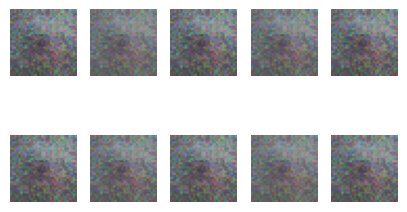

Epoch [1/120], Batch [0/1563], D Loss: 0.3039, G Loss: 3.0742
Epoch [1/120], Batch [100/1563], D Loss: 0.2814, G Loss: 3.8643
Epoch [1/120], Batch [200/1563], D Loss: 0.3686, G Loss: 1.5382
Epoch [1/120], Batch [300/1563], D Loss: 0.3834, G Loss: 1.5690
Epoch [1/120], Batch [400/1563], D Loss: 0.2608, G Loss: 2.3855
Epoch [1/120], Batch [500/1563], D Loss: 0.3544, G Loss: 3.6694
Epoch [1/120], Batch [600/1563], D Loss: 0.4054, G Loss: 3.3199
Epoch [1/120], Batch [700/1563], D Loss: 0.2955, G Loss: 3.3429
Epoch [1/120], Batch [800/1563], D Loss: 0.3487, G Loss: 2.5004
Epoch [1/120], Batch [900/1563], D Loss: 0.2992, G Loss: 2.5329
Epoch [1/120], Batch [1000/1563], D Loss: 0.2563, G Loss: 3.5773
Epoch [1/120], Batch [1100/1563], D Loss: 0.2653, G Loss: 2.6203
Epoch [1/120], Batch [1200/1563], D Loss: 0.2667, G Loss: 3.3438
Epoch [1/120], Batch [1300/1563], D Loss: 0.3267, G Loss: 1.9153
Epoch [1/120], Batch [1400/1563], D Loss: 0.3643, G Loss: 2.5570
Epoch [1/120], Batch [1500/1563], D L

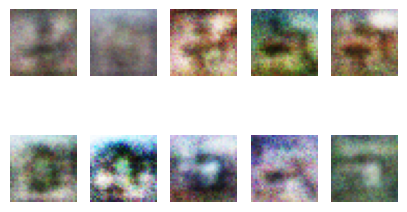

Epoch [11/120], Batch [0/1563], D Loss: 0.6711, G Loss: 0.9616
Epoch [11/120], Batch [100/1563], D Loss: 0.6872, G Loss: 0.9005
Epoch [11/120], Batch [200/1563], D Loss: 0.6732, G Loss: 0.8808
Epoch [11/120], Batch [300/1563], D Loss: 0.6836, G Loss: 0.9093
Epoch [11/120], Batch [400/1563], D Loss: 0.6870, G Loss: 0.8899
Epoch [11/120], Batch [500/1563], D Loss: 0.6661, G Loss: 0.9703
Epoch [11/120], Batch [600/1563], D Loss: 0.6797, G Loss: 0.9184
Epoch [11/120], Batch [700/1563], D Loss: 0.6543, G Loss: 0.9505
Epoch [11/120], Batch [800/1563], D Loss: 0.7099, G Loss: 0.8144
Epoch [11/120], Batch [900/1563], D Loss: 0.7303, G Loss: 0.8995
Epoch [11/120], Batch [1000/1563], D Loss: 0.6748, G Loss: 0.9363
Epoch [11/120], Batch [1100/1563], D Loss: 0.6886, G Loss: 0.9277
Epoch [11/120], Batch [1200/1563], D Loss: 0.6667, G Loss: 0.8872
Epoch [11/120], Batch [1300/1563], D Loss: 0.7563, G Loss: 0.9222
Epoch [11/120], Batch [1400/1563], D Loss: 0.6407, G Loss: 0.9802
Epoch [11/120], Batch 

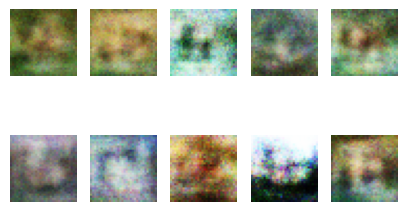

Epoch [21/120], Batch [0/1563], D Loss: 0.6741, G Loss: 0.7932
Epoch [21/120], Batch [100/1563], D Loss: 0.6810, G Loss: 0.8137
Epoch [21/120], Batch [200/1563], D Loss: 0.6806, G Loss: 0.8339
Epoch [21/120], Batch [300/1563], D Loss: 0.6981, G Loss: 0.7958
Epoch [21/120], Batch [400/1563], D Loss: 0.6903, G Loss: 0.8396
Epoch [21/120], Batch [500/1563], D Loss: 0.6764, G Loss: 0.8407
Epoch [21/120], Batch [600/1563], D Loss: 0.6705, G Loss: 0.8154
Epoch [21/120], Batch [700/1563], D Loss: 0.6866, G Loss: 0.8459
Epoch [21/120], Batch [800/1563], D Loss: 0.6901, G Loss: 0.8401
Epoch [21/120], Batch [900/1563], D Loss: 0.6522, G Loss: 0.8601
Epoch [21/120], Batch [1000/1563], D Loss: 0.7029, G Loss: 0.8922
Epoch [21/120], Batch [1100/1563], D Loss: 0.7159, G Loss: 0.7982
Epoch [21/120], Batch [1200/1563], D Loss: 0.6951, G Loss: 0.8125
Epoch [21/120], Batch [1300/1563], D Loss: 0.6870, G Loss: 0.8258
Epoch [21/120], Batch [1400/1563], D Loss: 0.6904, G Loss: 0.8041
Epoch [21/120], Batch 

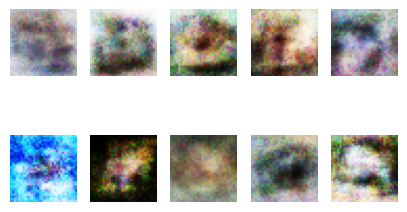

Epoch [31/120], Batch [0/1563], D Loss: 0.6723, G Loss: 0.8371
Epoch [31/120], Batch [100/1563], D Loss: 0.6983, G Loss: 0.8146
Epoch [31/120], Batch [200/1563], D Loss: 0.6739, G Loss: 0.8134
Epoch [31/120], Batch [300/1563], D Loss: 0.7012, G Loss: 0.7989
Epoch [31/120], Batch [400/1563], D Loss: 0.7017, G Loss: 0.8009
Epoch [31/120], Batch [500/1563], D Loss: 0.6969, G Loss: 0.8097
Epoch [31/120], Batch [600/1563], D Loss: 0.6854, G Loss: 0.8140
Epoch [31/120], Batch [700/1563], D Loss: 0.6758, G Loss: 0.8121
Epoch [31/120], Batch [800/1563], D Loss: 0.6821, G Loss: 0.7830
Epoch [31/120], Batch [900/1563], D Loss: 0.7077, G Loss: 0.7973
Epoch [31/120], Batch [1000/1563], D Loss: 0.6872, G Loss: 0.8396
Epoch [31/120], Batch [1100/1563], D Loss: 0.6897, G Loss: 0.7729
Epoch [31/120], Batch [1200/1563], D Loss: 0.6774, G Loss: 0.8015
Epoch [31/120], Batch [1300/1563], D Loss: 0.7053, G Loss: 0.7749
Epoch [31/120], Batch [1400/1563], D Loss: 0.6726, G Loss: 0.8278
Epoch [31/120], Batch 

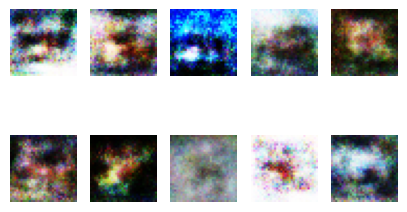

Epoch [41/120], Batch [0/1563], D Loss: 0.6953, G Loss: 0.7664
Epoch [41/120], Batch [100/1563], D Loss: 0.6828, G Loss: 0.8315
Epoch [41/120], Batch [200/1563], D Loss: 0.6736, G Loss: 0.7946
Epoch [41/120], Batch [300/1563], D Loss: 0.7000, G Loss: 0.7836
Epoch [41/120], Batch [400/1563], D Loss: 0.7016, G Loss: 0.7879
Epoch [41/120], Batch [500/1563], D Loss: 0.6690, G Loss: 0.7735
Epoch [41/120], Batch [600/1563], D Loss: 0.6917, G Loss: 0.8366
Epoch [41/120], Batch [700/1563], D Loss: 0.6596, G Loss: 0.8511
Epoch [41/120], Batch [800/1563], D Loss: 0.6952, G Loss: 0.7963
Epoch [41/120], Batch [900/1563], D Loss: 0.7012, G Loss: 0.8059
Epoch [41/120], Batch [1000/1563], D Loss: 0.6917, G Loss: 0.8440
Epoch [41/120], Batch [1100/1563], D Loss: 0.6824, G Loss: 0.7899
Epoch [41/120], Batch [1200/1563], D Loss: 0.6758, G Loss: 0.8010
Epoch [41/120], Batch [1300/1563], D Loss: 0.6896, G Loss: 0.7617
Epoch [41/120], Batch [1400/1563], D Loss: 0.6918, G Loss: 0.8248
Epoch [41/120], Batch 

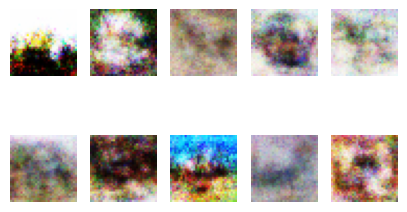

Epoch [51/120], Batch [0/1563], D Loss: 0.6793, G Loss: 0.8131
Epoch [51/120], Batch [100/1563], D Loss: 0.7032, G Loss: 0.8136
Epoch [51/120], Batch [200/1563], D Loss: 0.6846, G Loss: 0.8175
Epoch [51/120], Batch [300/1563], D Loss: 0.6660, G Loss: 0.8295
Epoch [51/120], Batch [400/1563], D Loss: 0.6826, G Loss: 0.7803
Epoch [51/120], Batch [500/1563], D Loss: 0.7057, G Loss: 0.8070
Epoch [51/120], Batch [600/1563], D Loss: 0.6791, G Loss: 0.8015
Epoch [51/120], Batch [700/1563], D Loss: 0.6979, G Loss: 0.8267
Epoch [51/120], Batch [800/1563], D Loss: 0.7041, G Loss: 0.8164
Epoch [51/120], Batch [900/1563], D Loss: 0.6800, G Loss: 0.8522
Epoch [51/120], Batch [1000/1563], D Loss: 0.6783, G Loss: 0.8152
Epoch [51/120], Batch [1100/1563], D Loss: 0.6744, G Loss: 0.7849
Epoch [51/120], Batch [1200/1563], D Loss: 0.6873, G Loss: 0.8096
Epoch [51/120], Batch [1300/1563], D Loss: 0.6890, G Loss: 0.8071
Epoch [51/120], Batch [1400/1563], D Loss: 0.6744, G Loss: 0.8321
Epoch [51/120], Batch 

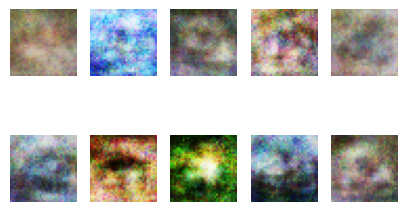

Epoch [61/120], Batch [0/1563], D Loss: 0.6723, G Loss: 0.8045
Epoch [61/120], Batch [100/1563], D Loss: 0.6775, G Loss: 0.7846
Epoch [61/120], Batch [200/1563], D Loss: 0.6763, G Loss: 0.7965
Epoch [61/120], Batch [300/1563], D Loss: 0.6823, G Loss: 0.7869
Epoch [61/120], Batch [400/1563], D Loss: 0.7115, G Loss: 0.7933
Epoch [61/120], Batch [500/1563], D Loss: 0.6859, G Loss: 0.8163
Epoch [61/120], Batch [600/1563], D Loss: 0.6971, G Loss: 0.8171
Epoch [61/120], Batch [700/1563], D Loss: 0.7085, G Loss: 0.8058
Epoch [61/120], Batch [800/1563], D Loss: 0.6872, G Loss: 0.8287
Epoch [61/120], Batch [900/1563], D Loss: 0.6935, G Loss: 0.7963
Epoch [61/120], Batch [1000/1563], D Loss: 0.6843, G Loss: 0.8141
Epoch [61/120], Batch [1100/1563], D Loss: 0.6842, G Loss: 0.8451
Epoch [61/120], Batch [1200/1563], D Loss: 0.7015, G Loss: 0.8075
Epoch [61/120], Batch [1300/1563], D Loss: 0.7018, G Loss: 0.7986
Epoch [61/120], Batch [1400/1563], D Loss: 0.6825, G Loss: 0.8240
Epoch [61/120], Batch 

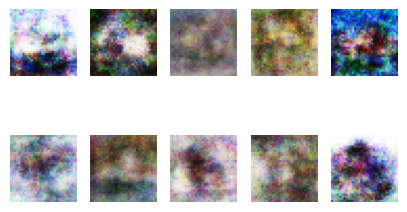

Epoch [71/120], Batch [0/1563], D Loss: 0.6813, G Loss: 0.8532
Epoch [71/120], Batch [100/1563], D Loss: 0.6823, G Loss: 0.7959
Epoch [71/120], Batch [200/1563], D Loss: 0.6810, G Loss: 0.8128
Epoch [71/120], Batch [300/1563], D Loss: 0.6877, G Loss: 0.8264
Epoch [71/120], Batch [400/1563], D Loss: 0.6888, G Loss: 0.7850
Epoch [71/120], Batch [500/1563], D Loss: 0.6796, G Loss: 0.8121
Epoch [71/120], Batch [600/1563], D Loss: 0.6856, G Loss: 0.7642
Epoch [71/120], Batch [700/1563], D Loss: 0.6718, G Loss: 0.8470
Epoch [71/120], Batch [800/1563], D Loss: 0.6902, G Loss: 0.8117
Epoch [71/120], Batch [900/1563], D Loss: 0.6947, G Loss: 0.7701
Epoch [71/120], Batch [1000/1563], D Loss: 0.6813, G Loss: 0.8031
Epoch [71/120], Batch [1100/1563], D Loss: 0.6936, G Loss: 0.8020
Epoch [71/120], Batch [1200/1563], D Loss: 0.7042, G Loss: 0.8393
Epoch [71/120], Batch [1300/1563], D Loss: 0.6877, G Loss: 0.8148
Epoch [71/120], Batch [1400/1563], D Loss: 0.6931, G Loss: 0.8258
Epoch [71/120], Batch 

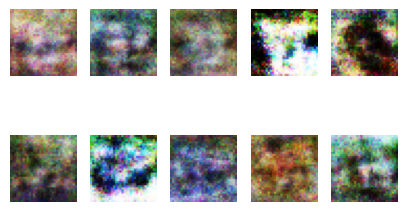

Epoch [81/120], Batch [0/1563], D Loss: 0.6769, G Loss: 0.7990
Epoch [81/120], Batch [100/1563], D Loss: 0.6877, G Loss: 0.7883
Epoch [81/120], Batch [200/1563], D Loss: 0.6536, G Loss: 0.8959
Epoch [81/120], Batch [300/1563], D Loss: 0.6982, G Loss: 0.8181
Epoch [81/120], Batch [400/1563], D Loss: 0.6872, G Loss: 0.8447
Epoch [81/120], Batch [500/1563], D Loss: 0.6925, G Loss: 0.8030
Epoch [81/120], Batch [600/1563], D Loss: 0.6783, G Loss: 0.7867
Epoch [81/120], Batch [700/1563], D Loss: 0.6993, G Loss: 0.8414
Epoch [81/120], Batch [800/1563], D Loss: 0.6652, G Loss: 0.8573
Epoch [81/120], Batch [900/1563], D Loss: 0.6791, G Loss: 0.7957
Epoch [81/120], Batch [1000/1563], D Loss: 0.6929, G Loss: 0.8025
Epoch [81/120], Batch [1100/1563], D Loss: 0.6725, G Loss: 0.8119
Epoch [81/120], Batch [1200/1563], D Loss: 0.6918, G Loss: 0.8330
Epoch [81/120], Batch [1300/1563], D Loss: 0.6911, G Loss: 0.8092
Epoch [81/120], Batch [1400/1563], D Loss: 0.6858, G Loss: 0.7843
Epoch [81/120], Batch 

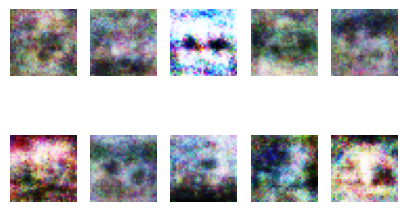

Epoch [91/120], Batch [0/1563], D Loss: 0.6809, G Loss: 0.7933
Epoch [91/120], Batch [100/1563], D Loss: 0.6940, G Loss: 0.7844
Epoch [91/120], Batch [200/1563], D Loss: 0.6977, G Loss: 0.7695
Epoch [91/120], Batch [300/1563], D Loss: 0.6745, G Loss: 0.7962
Epoch [91/120], Batch [400/1563], D Loss: 0.6739, G Loss: 0.7908
Epoch [91/120], Batch [500/1563], D Loss: 0.6884, G Loss: 0.7937
Epoch [91/120], Batch [600/1563], D Loss: 0.7059, G Loss: 0.7884
Epoch [91/120], Batch [700/1563], D Loss: 0.6871, G Loss: 0.8122
Epoch [91/120], Batch [800/1563], D Loss: 0.6771, G Loss: 0.8173
Epoch [91/120], Batch [900/1563], D Loss: 0.6863, G Loss: 0.7957
Epoch [91/120], Batch [1000/1563], D Loss: 0.6930, G Loss: 0.7791
Epoch [91/120], Batch [1100/1563], D Loss: 0.6935, G Loss: 0.7610
Epoch [91/120], Batch [1200/1563], D Loss: 0.6893, G Loss: 0.7962
Epoch [91/120], Batch [1300/1563], D Loss: 0.6655, G Loss: 0.8425
Epoch [91/120], Batch [1400/1563], D Loss: 0.6959, G Loss: 0.8030
Epoch [91/120], Batch 

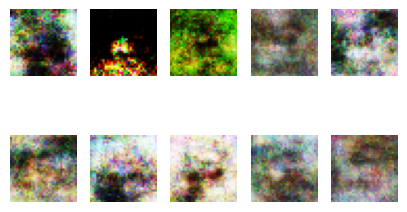

Epoch [101/120], Batch [0/1563], D Loss: 0.6805, G Loss: 0.8042
Epoch [101/120], Batch [100/1563], D Loss: 0.6867, G Loss: 0.8254
Epoch [101/120], Batch [200/1563], D Loss: 0.6697, G Loss: 0.7640
Epoch [101/120], Batch [300/1563], D Loss: 0.6806, G Loss: 0.8349
Epoch [101/120], Batch [400/1563], D Loss: 0.6961, G Loss: 0.8326
Epoch [101/120], Batch [500/1563], D Loss: 0.6849, G Loss: 0.8420
Epoch [101/120], Batch [600/1563], D Loss: 0.6874, G Loss: 0.7903
Epoch [101/120], Batch [700/1563], D Loss: 0.6855, G Loss: 0.8273
Epoch [101/120], Batch [800/1563], D Loss: 0.7053, G Loss: 0.7682
Epoch [101/120], Batch [900/1563], D Loss: 0.6881, G Loss: 0.8187
Epoch [101/120], Batch [1000/1563], D Loss: 0.7106, G Loss: 0.8168
Epoch [101/120], Batch [1100/1563], D Loss: 0.6669, G Loss: 0.7779
Epoch [101/120], Batch [1200/1563], D Loss: 0.7198, G Loss: 0.8064
Epoch [101/120], Batch [1300/1563], D Loss: 0.6909, G Loss: 0.8087
Epoch [101/120], Batch [1400/1563], D Loss: 0.6802, G Loss: 0.8159
Epoch [

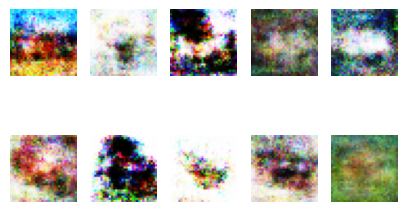

Epoch [111/120], Batch [0/1563], D Loss: 0.6837, G Loss: 0.8168
Epoch [111/120], Batch [100/1563], D Loss: 0.6769, G Loss: 0.8437
Epoch [111/120], Batch [200/1563], D Loss: 0.6814, G Loss: 0.8032
Epoch [111/120], Batch [300/1563], D Loss: 0.6922, G Loss: 0.8037
Epoch [111/120], Batch [400/1563], D Loss: 0.6804, G Loss: 0.8008
Epoch [111/120], Batch [500/1563], D Loss: 0.6890, G Loss: 0.8335
Epoch [111/120], Batch [600/1563], D Loss: 0.6735, G Loss: 0.7739
Epoch [111/120], Batch [700/1563], D Loss: 0.6890, G Loss: 0.8088
Epoch [111/120], Batch [800/1563], D Loss: 0.6720, G Loss: 0.7839
Epoch [111/120], Batch [900/1563], D Loss: 0.6740, G Loss: 0.7781
Epoch [111/120], Batch [1000/1563], D Loss: 0.6944, G Loss: 0.7959
Epoch [111/120], Batch [1100/1563], D Loss: 0.7096, G Loss: 0.7980
Epoch [111/120], Batch [1200/1563], D Loss: 0.6827, G Loss: 0.8020
Epoch [111/120], Batch [1300/1563], D Loss: 0.6844, G Loss: 0.7928
Epoch [111/120], Batch [1400/1563], D Loss: 0.6804, G Loss: 0.8261
Epoch [

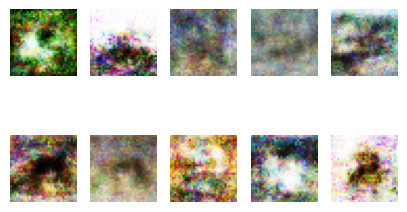

In [8]:
# Training loop
epochs = 120
batch_size = 32
smooth = 0.1

d_loss_history = []
g_loss_history = []

for epoch in range(epochs + 1):
    for i, (real_images, _) in enumerate(train_loader):
        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        real_labels = torch.full((batch_size, 1), 1 - smooth, device=device)
        fake_labels = torch.zeros((batch_size, 1), device=device)

        # Train Discriminator
        optimizer_D.zero_grad()
        outputs = discriminator(real_images)
        d_loss_real = criterion(outputs, real_labels)

        z = torch.randn(batch_size, latent_dim, device=device)
        fake_images = generator(z)
        outputs = discriminator(fake_images.detach())
        d_loss_fake = criterion(outputs, fake_labels)

        d_loss = (d_loss_real + d_loss_fake) / 2
        d_loss.backward()
        optimizer_D.step()

        # Train Generator
        optimizer_G.zero_grad()
        outputs = discriminator(fake_images)
        g_loss = criterion(outputs, real_labels)
        g_loss.backward()
        optimizer_G.step()

        if i % 100 == 0:
            print(f"Epoch [{epoch}/{epochs}], Batch [{i}/{len(train_loader)}], D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}")

    d_loss_history.append(d_loss.item())
    g_loss_history.append(g_loss.item())

    if epoch % 10 == 0:
        generator.eval()
        with torch.no_grad():
            z = torch.randn(10, latent_dim, device=device)
            fake_images = generator(z).cpu().permute(0, 2, 3, 1).numpy()
            fake_images = (fake_images + 1) / 2  # Rescale to [0,1]

        fig, axes = plt.subplots(2, 5, figsize=(5, 3))
        for ax, img in zip(axes.flatten(), fake_images):
            ax.imshow(img)
            ax.axis('off')
        plt.show()
        generator.train()

After the training ends we plot the losses. we observe that Generator Loss starts very high , meaning the Generator initially produces poor-quality images, then it drops quickly, showing that G is improving, then it stabilizes around 1.0, indicating a steady learning process. Discriminator Loss starts low but increases initially, meaning the Discriminatoe is learning to differentiate real and fake images and then it stabilizes.

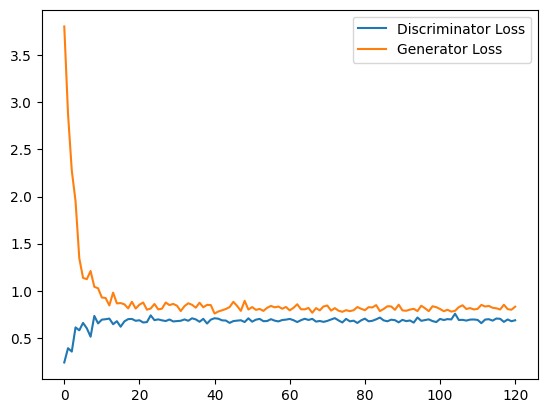

In [9]:
# Plot loss
plt.plot(d_loss_history, label="Discriminator Loss")
plt.plot(g_loss_history, label="Generator Loss")
plt.legend()
plt.show()

In [10]:
# Save the generator model
torch.save(generator.state_dict(), 'generatorGAN.pth')

# Save the discriminator model
torch.save(discriminator.state_dict(), 'discriminatorGAN.pth')

The following steps is to display some of the generated images. we notice the images are of poor quality. However, in the next part we will use deep convolotioal GAN and compare both results.

In [11]:
# Load the generator model
generator = Generator(latent_dim)  # Replace with your generator class
generator.load_state_dict(torch.load('generatorGAN.pth'))
generator.eval()  # Set to evaluation mode if you're generating images

# Load the discriminator model
discriminator = Discriminator()  # Replace with your discriminator class
discriminator.load_state_dict(torch.load('discriminatorGAN.pth'))
discriminator.eval()  # Set to evaluation mode if needed

Discriminator(
  (model): Sequential(
    (0): Linear(in_features=3072, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

In [12]:
generator

Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): ReLU()
    (6): Linear(in_features=1024, out_features=3072, bias=True)
    (7): Tanh()
  )
)

In [13]:
generator.to(device)

# Generate random noise
noise = torch.randn( 64,100, device=device)  # Adjust dimensions as needed

# Generate images
with torch.no_grad():
    generated_images = generator(noise)

In [14]:
generated_images = generated_images.detach().cpu().numpy()
generated_images = (generated_images + 1) / 2

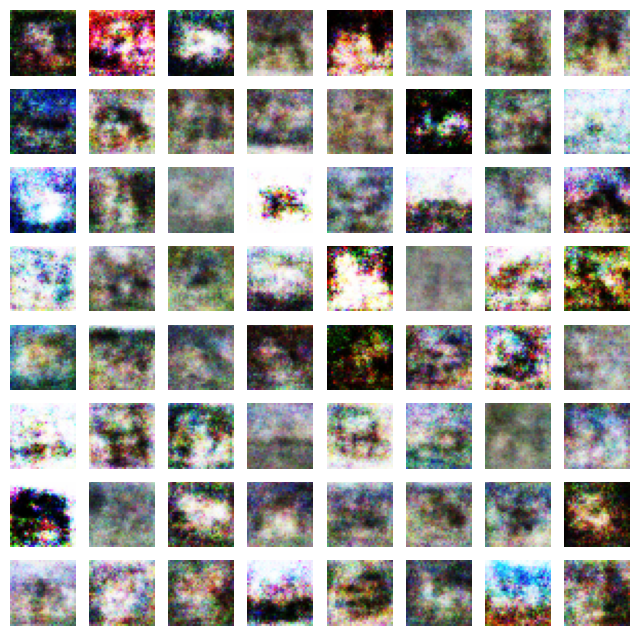

In [15]:
# Plotting the images
fig, axes = plt.subplots(nrows=8, ncols=8, figsize=(8, 8))
for i in range(64):
    ax = axes[i // 8, i % 8]
    ax.imshow(generated_images[i].transpose(1, 2, 0))  # Change shape from (C, H, W) to (H, W, C)
    ax.axis('off')
plt.show()